In [87]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
import pandas as pd

In [88]:
iris = datasets.load_iris()
df = pd.read_csv("dataset_train.csv")
# print(df.describe()['mean'])
# print(df.dtypes)
house = {'Slytherin':1, 
         'Gryffindor':2,
         'Hufflepuff':3,
         "Ravenclaw":4}
# display(df.head(10))
df['hous_index'] = df['Hogwarts House'].map(house)
display(df.head(5))
# Which Hogwarts class has an homogenous grade repartition between the four houses?
trian_df = df.select_dtypes("number")
trian_df = trian_df.drop(columns=['Index'], axis=1)
display(trian_df.head())


,Index,Hogwarts House,First Name,Last Name,Birthday,Best Hand,Arithmancy,Astronomy,Herbology,Defense Against the Dark Arts,Divination,Muggle Studies,Ancient Runes,History of Magic,Transfiguration,Potions,Care of Magical Creatures,Charms,Flying,hous_index
0,0,Ravenclaw,Tamara,Hsu,2000-03-30,Left,58384.0,-487.886086,5.727180,4.878861,4.722,272.035831,532.484226,5.231058,1039.788281,3.790369,0.715939,-232.79405,-26.89,4
1,1,Slytherin,Erich,Paredes,1999-10-14,Right,67239.0,-552.060507,-5.987446,5.520605,-5.612,-487.340557,367.760303,4.107170,1058.944592,7.248742,0.091674,-252.18425,-113.45,1
2,2,Ravenclaw,Stephany,Braun,1999-11-03,Left,23702.0,-366.076117,7.725017,3.660761,6.140,664.893521,602.585284,3.555579,1088.088348,8.728531,-0.515327,-227.34265,30.42,4
3,3,Gryffindor,Vesta,Mcmichael,2000-08-19,Left,32667.0,697.742809,-6.497214,-6.977428,4.026,-537.001128,523.982133,-4.809637,920.391449,0.821911,-0.014040,-256.84675,200.64,2
4,4,Gryffindor,Gaston,Gibbs,1998-09-27,Left,60158.0,436.775204,-7.820623,NaN,2.236,-444.262537,599.324514,-3.444377,937.434724,4.311066,-0.264070,-256.38730,157.98,2


,Arithmancy,Astronomy,Herbology,Defense Against the Dark Arts,Divination,Muggle Studies,Ancient Runes,History of Magic,Transfiguration,Potions,Care of Magical Creatures,Charms,Flying,hous_index
0,58384.0,-487.886086,5.727180,4.878861,4.722,272.035831,532.484226,5.231058,1039.788281,3.790369,0.715939,-232.79405,-26.89,4
1,67239.0,-552.060507,-5.987446,5.520605,-5.612,-487.340557,367.760303,4.107170,1058.944592,7.248742,0.091674,-252.18425,-113.45,1
2,23702.0,-366.076117,7.725017,3.660761,6.140,664.893521,602.585284,3.555579,1088.088348,8.728531,-0.515327,-227.34265,30.42,4
3,32667.0,697.742809,-6.497214,-6.977428,4.026,-537.001128,523.982133,-4.809637,920.391449,0.821911,-0.014040,-256.84675,200.64,2
4,60158.0,436.775204,-7.820623,NaN,2.236,-444.262537,599.324514,-3.444377,937.434724,4.311066,-0.264070,-256.38730,157.98,2


In [105]:
X = iris.data[:, :2]
new_df = df[['Astronomy', 'Herbology']].copy()
print(new_df['Astronomy'].isnull().sum())

# new_df = new_df.apply(lambda x: x.fillna(x.mean()), axis=0)
new_df = new_df.dropna()
# X = new_df.to_numpy()
# every cell == 2 => 0 else = 0
y = (iris.target != 0 ) * 1
# y = y.to_numpy()
display(y)
display(X)
simulated_labels = y
simulated_separableish_features = X



32


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

array([[5.1, 3.5],
       [4.9, 3. ],
       [4.7, 3.2],
       [4.6, 3.1],
       [5. , 3.6],
       [5.4, 3.9],
       [4.6, 3.4],
       [5. , 3.4],
       [4.4, 2.9],
       [4.9, 3.1],
       [5.4, 3.7],
       [4.8, 3.4],
       [4.8, 3. ],
       [4.3, 3. ],
       [5.8, 4. ],
       [5.7, 4.4],
       [5.4, 3.9],
       [5.1, 3.5],
       [5.7, 3.8],
       [5.1, 3.8],
       [5.4, 3.4],
       [5.1, 3.7],
       [4.6, 3.6],
       [5.1, 3.3],
       [4.8, 3.4],
       [5. , 3. ],
       [5. , 3.4],
       [5.2, 3.5],
       [5.2, 3.4],
       [4.7, 3.2],
       [4.8, 3.1],
       [5.4, 3.4],
       [5.2, 4.1],
       [5.5, 4.2],
       [4.9, 3.1],
       [5. , 3.2],
       [5.5, 3.5],
       [4.9, 3.6],
       [4.4, 3. ],
       [5.1, 3.4],
       [5. , 3.5],
       [4.5, 2.3],
       [4.4, 3.2],
       [5. , 3.5],
       [5.1, 3.8],
       [4.8, 3. ],
       [5.1, 3.8],
       [4.6, 3.2],
       [5.3, 3.7],
       [5. , 3.3],
       [7. , 3.2],
       [6.4, 3.2],
       [6.9,

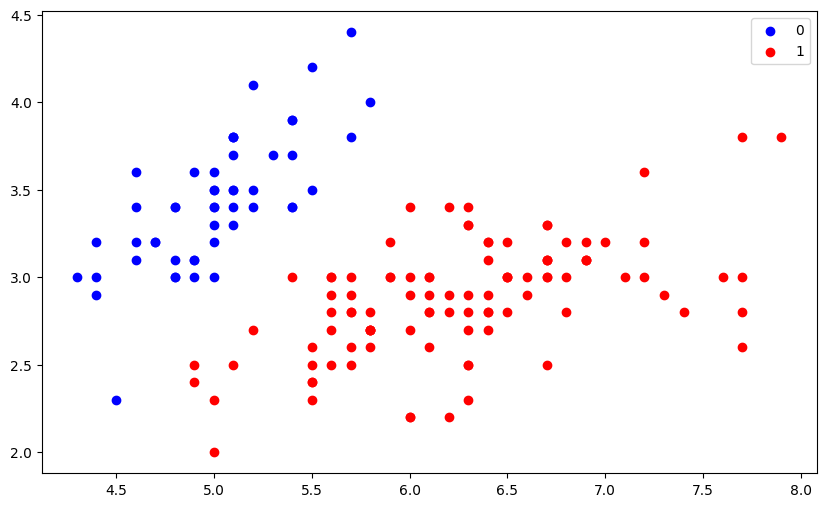

In [99]:
plt.figure(figsize=(10, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='b', label='0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='r', label='1')
plt.legend();

In [104]:
from sklearn.preprocessing import minmax_scale
# X = minmax_scale(X, feature_range=(0,1), axis=0)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def log_likelihood(features, target, weights):
    scores = np.dot(features, weights)
    ll = np.sum( target * scores - np.log(1 + np.exp(scores)) )
    return ll

def logistic_regression(features, target, num_steps, learning_rate, add_intercept = False):
    if add_intercept:
        intercept = np.ones((features.shape[0], 1))
        print(intercept.shape[0])
        features = np.hstack((intercept, features))
        
    weights = np.zeros(features.shape[1])
    
    for step in range(num_steps):
        scores = np.dot(features, weights)
        predictions = sigmoid(scores)

        # Update weights with log likelihood gradient
        output_error_signal = target - predictions
        
        gradient = np.dot(features.T, output_error_signal)
        weights += learning_rate * gradient

        # Print log-likelihood every so often
        if step % 10000 == 0:
            print ("log like hood ",log_likelihood(features, target, weights))
        
    return weights   
            
    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_predicted = sigmoid(linear_model)
        # Convert probabilities to binary outcomes
        y_predicted_class = [1 if i > 0.5 else 0 for i in y_predicted]
        return np.array(y_predicted_class)

weights = logistic_regression(simulated_separableish_features, simulated_labels,
                     num_steps = 500000, learning_rate = 5e-5, add_intercept=True)
print("weights=====>" ,weights)


150
log like hood  -102.08729794722788
log like hood  -14.916403894689577
log like hood  -10.31891057748258
log like hood  -8.548387929507012
log like hood  -7.582819071028489
log like hood  -6.96457520991934
log like hood  -6.529600114626367
log like hood  -6.20377807844617
log like hood  -5.948485174424648
log like hood  -5.741523590944502
log like hood  -5.5691894676958515
log like hood  -5.422546859911483
log like hood  -5.295511313473728
log like hood  -5.183792073407195
log like hood  -5.084274193567367
log like hood  -4.994640416951443
log like hood  -4.91313059804391
log like hood  -4.838383488016394
log like hood  -4.769329681042512
log like hood  -4.705117361794544
log like hood  -4.645059671642879
log like hood  -4.588596674022385
log like hood  -4.535267393686109
log like hood  -4.484688942599657
log like hood  -4.436540718239151
log like hood  -4.3905522899281255
log like hood  -4.346494005140053
log like hood  -4.304169628052516
log like hood  -4.263410514719425
log like 

In [101]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(fit_intercept=True, max_iter=1000000, C=5e-5)
clf.fit(X, y)



LogisticRegression(C=5e-05, max_iter=1000000)

In [103]:
print(clf.coef_)

[[ 0.00209109 -0.00092588]]
